<a href="https://colab.research.google.com/github/Ludashi47/Linked-data-OperaSampo/blob/main/BiographySampo_examples_Hack4OpenGlam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[BiographySampo](http://biografiasampo.fi/haku/ruudukko) open data query examples

# Environment setup

## *Install* the dependencies:

In [1]:
!pip install SPARQLWrapper numpy scipy matplotlib pandas networkx itables
%matplotlib inline

from datetime import datetime
from dateutil.relativedelta import relativedelta

import matplotlib.pyplot as plt
import numpy    as np
import networkx as nx
import pandas   as pd

from collections import Counter, OrderedDict
from itables import init_notebook_mode
from rdflib import URIRef
from rdflib.namespace import XSD, Namespace
from scipy.stats import binned_statistic
from scipy.interpolate import interp1d
from SPARQLWrapper import SPARQLWrapper, JSON, POST
from IPython.display import display, HTML

from itertools import combinations
import seaborn as sns

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 362, in run
    resolver = self.make_resolver(
               ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 177, in make_resolver
    return pip._internal.resolution.resolvelib.resolver.Resolver(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/resolution/resolvelib/resolver.py", line 58, in __init__
    self.factory = Factory(
                   ^^^^^^^^
  File "/usr/local/lib/py

KeyboardInterrupt: 

## Define some useful functions for data conversion

In [ ]:
from rdflib.namespace import XSD
import pandas as pd

DATATYPECONVERTERS = {
      str(XSD.integer):  int,
      str(XSD.decimal):  float,
      str(XSD.date):     lambda v: datetime.strptime(v, '%Y-%m-%d').date(),
      str(XSD.dateTime): lambda v: datetime.strptime(v, '%Y-%m-%dT%H:%M:%S').date()
  }

def convertDatatype(obj):
  return DATATYPECONVERTERS.get(obj.get('datatype'), str)(obj.get('value'))

def JSON2Pandas(results):
    res = results["results"]["bindings"]
    data = [dict([(k, convertDatatype(v)) for k,v in r.items()]) for r in res]
    return pd.DataFrame(data)

def convertDatatypes(results):
    res = results["results"]["bindings"]
    return [dict([(k, convertDatatype(v)) for k,v in r.items()]) for r in res]

## Constants for category example

In [ ]:
CATS = Namespace('http://ldf.fi/nbf/categories/')

CATEGORY_LOOKUP = {
    CATS.c74: 'Economics',
    CATS.c75: 'Economics',
    CATS.c71: 'Economics',
    CATS.c72: 'Economics',
    CATS.c73: 'Economics',
    CATS.c76: 'Economics',
    CATS.c131: 'Politics',
    CATS.c132: 'Politics',
    CATS.c133: 'Politics',
    CATS.c39: 'Science',
    CATS.c38: 'Science',
    CATS.c381: 'Science',
    CATS.c382: 'Science',
    CATS.c34: 'Science',
    CATS.c341: 'Science',
    CATS.c342: 'Science',
    CATS.c31: 'Science',
    CATS.c37: 'Science', # 'theology')
    CATS.c35: 'Science',
    CATS.c33: 'Science',
    CATS.c32: 'Science',
    CATS.c36: 'Science',
    CATS.c44: 'Culture', # 'art and music',
    CATS.c41: 'Culture', # 'art and music',
    CATS.c43: 'Culture', # 'art and music',
    CATS.c46: 'Culture', # writers
    CATS.c47: 'Culture', # poets
    CATS.c42: 'Culture',
    CATS.c48: 'Culture', # kirjastot, arkistot, museot
    CATS.c45: 'Culture',
    CATS.c12: 'Military',
    CATS.c51: 'Sports',
    CATS.c52: 'Sports',
    CATS.c5121: 'Sports',
    CATS.c61: 'Religion', # 'lutherians')
    CATS.c62: 'Religion', # 'catholics')
    CATS.c63: 'Religion', # ortodoksit
    CATS.c64: 'Religion', # muut uskonnot
    CATS.c21: 'Education',
    CATS.c22: 'Education',
    CATS.c81: 'Communications',
    CATS.c82: 'Communications',
    CATS.c83: 'Communications',
    CATS.c101: 'Civil Servants',
    CATS.c102: 'Civil Servants',
    CATS.c103: 'Civil Servants',
    CATS.c91: 'Charitable and NGO',
    CATS.c92: 'Charitable and NGO',
    CATS.c93: 'Charitable and NGO',
    CATS.c94: 'Charitable and NGO',
    CATS.c111: 'Judiciary',
    CATS.c112: 'Judiciary'
}

# Example of querying person data, people related to Helsinki
(open same query in [yasgui.com](https://api.triplydb.com/s/0sbPrbw2)) from [BiographySampo](http://www.ldf.fi/dataset/nbf) linked data endpoint

In [ ]:
sparql = SPARQLWrapper("http://ldf.fi/nbf/sparql")
sparql.setQuery("""
PREFIX crm:     <http://www.cidoc-crm.org/cidoc-crm/>
PREFIX dct:     <http://purl.org/dc/terms/>
PREFIX foaf:    <http://xmlns.com/foaf/0.1/>
PREFIX gvp:     <http://vocab.getty.edu/ontology#>
PREFIX schema:  <http://schema.org/>
PREFIX skosxl:  <http://www.w3.org/2008/05/skos-xl#>
PREFIX skos:    <http://www.w3.org/2004/02/skos/core#>

PREFIX nbf:     <http://ldf.fi/nbf/>
PREFIX sources: <http://ldf.fi/nbf/sources/>

SELECT DISTINCT ?id ?fname ?gname ?gender ?birthtime ?birthplace ?deathtime ?deathplace WHERE {

  VALUES ?placename { "Helsinki"@fi }

  #	birth event
  ?evt nbf:place/skos:prefLabel ?birthplace ;
       crm:P98_brought_into_life/^foaf:focus ?id ;
       nbf:time/gvp:estStart ?birthtime .

  #	death event
  ?evt2 crm:P100_was_death_of/^foaf:focus ?id ;
       nbf:place/skos:prefLabel ?deathplace ;
       nbf:time/gvp:estStart ?deathtime .

  FILTER (?birthplace=?placename || ?deathplace=?placename)
  ?id dct:source sources:source1 ;
    	skosxl:prefLabel [ schema:familyName ?fname ; schema:givenName ?gname ] ;
    	foaf:focus/nbf:sukupuoli ?gender .

} ORDER BY ?birthtime
""")

sparql.setReturnFormat(JSON)

results = sparql.query().convert()

Report information about the query results and show the JSON format


In [ ]:
res = results["results"]["bindings"]
print(f"{len(res)} results")

print(f"Datafields {results['head']['vars']}")

for ob in res[:5]:
  print(ob)

2509 results
Datafields ['id', 'fname', 'gname', 'gender', 'birthtime', 'birthplace', 'deathtime', 'deathplace']
{'id': {'type': 'uri', 'value': 'http://ldf.fi/nbf/p5307'}, 'fname': {'type': 'literal', 'xml:lang': 'fi', 'value': 'van Sanden'}, 'gname': {'type': 'literal', 'xml:lang': 'fi', 'value': 'Hans'}, 'gender': {'type': 'literal', 'xml:lang': 'fi', 'value': 'mies'}, 'birthtime': {'type': 'literal', 'datatype': 'http://www.w3.org/2001/XMLSchema#date', 'value': '1500-01-01'}, 'birthplace': {'type': 'literal', 'xml:lang': 'fi', 'value': 'Hollanti'}, 'deathtime': {'type': 'literal', 'datatype': 'http://www.w3.org/2001/XMLSchema#date', 'value': '1590-01-01'}, 'deathplace': {'type': 'literal', 'xml:lang': 'fi', 'value': 'Helsinki'}}
{'id': {'type': 'uri', 'value': 'http://ldf.fi/nbf/p629'}, 'fname': {'type': 'literal', 'xml:lang': 'fi', 'value': 'Forsius'}, 'gname': {'type': 'literal', 'xml:lang': 'fi', 'value': 'Sigfridus Aronus'}, 'gender': {'type': 'literal', 'xml:lang': 'fi', 'valu

## Convert to a [pandas](https://pandas.pydata.org) DataFrame

In [ ]:
init_notebook_mode(all_interactive=True)

df = JSON2Pandas(results)
df.set_index('id', inplace=True)
display(df)

fname              gname  gender   birthtime  \
id                                                                           
http://ldf.fi/nbf/p5307  van Sanden               Hans    mies  1500-01-01   
http://ldf.fi/nbf/p629      Forsius   Sigfridus Aronus    mies  1560-01-01   
http://ldf.fi/nbf/p248   Nycopensis  Andreas Laurentii    mies  1600-01-01   
http://ldf.fi/nbf/p757      Hartman             Samuel    mies  1606-01-01   
http://ldf.fi/nbf/p258   Carstenius           Henricus    mies  1612-05-25   
...                             ...                ...     ...         ...   
http://ldf.fi/nbf/p6473     Melleri               Arto    mies  1956-09-07   
http://ldf.fi/nbf/p6472    Salminen               Arto    mies  1959-10-22   
http://ldf.fi/nbf/p6221  Lehtikuusi            Hannele  nainen  1960-02-20   
http://ldf.fi/nbf/p6410      Kotila             Heikki    mies  1960-07-10   
http://ldf.fi/nbf/p6467      Lundán               Reko    mies  1969-04-02   

                         birthplace   deathtime  deathplace  
id                                                           
http://ldf.fi/nbf/p5307    Hollanti  1590-01-01    Helsinki  
http://ldf.fi/nbf/p629     Helsinki  1624-01-01  Tammisaari  
http://ldf.fi/nbf/p248     Nyköping  1688-01-01    Helsinki  
http://ldf.fi/nbf/p757     Helsinki  1653-01-01       Turku  
http://ldf.fi/nbf/p258     Helsinki  1683-01-01     Viipuri  
...                             ...         ...         ...  
http://ldf.fi/nbf/p6473  Lappajärvi  2005-01-01    Helsinki  
http://ldf.fi/nbf/p6472    Helsinki  2005-01-01   Hausjärvi  
http://ldf.fi/nbf/p6221       Kitee  2004-01-01    Helsinki  
http://ldf.fi/nbf/p6410   Toholampi  2010-01-01    Helsinki  
http://ldf.fi/nbf/p6467   Janakkala  2006-01-01    Helsinki  

[2509 rows x 7 columns]

### Add a new data field with full name by concatenating the given and family names:

In [ ]:
df['fullname'] = df['gname']+ ' ' +df['fname']

### Add a new data field by calculating the age in years

In [ ]:
df['age'] = df.apply(lambda x: relativedelta(x.deathtime, x.birthtime).years, axis=1)

Show the modified dataframe

In [ ]:
display(df)

fname              gname  gender   birthtime  \
id                                                                           
http://ldf.fi/nbf/p5307  van Sanden               Hans    mies  1500-01-01   
http://ldf.fi/nbf/p629      Forsius   Sigfridus Aronus    mies  1560-01-01   
http://ldf.fi/nbf/p248   Nycopensis  Andreas Laurentii    mies  1600-01-01   
http://ldf.fi/nbf/p757      Hartman             Samuel    mies  1606-01-01   
http://ldf.fi/nbf/p258   Carstenius           Henricus    mies  1612-05-25   
...                             ...                ...     ...         ...   
http://ldf.fi/nbf/p6473     Melleri               Arto    mies  1956-09-07   
http://ldf.fi/nbf/p6472    Salminen               Arto    mies  1959-10-22   
http://ldf.fi/nbf/p6221  Lehtikuusi            Hannele  nainen  1960-02-20   
http://ldf.fi/nbf/p6410      Kotila             Heikki    mies  1960-07-10   
http://ldf.fi/nbf/p6467      Lundán               Reko    mies  1969-04-02   

                         birthplace   deathtime  deathplace  \
id                                                            
http://ldf.fi/nbf/p5307    Hollanti  1590-01-01    Helsinki   
http://ldf.fi/nbf/p629     Helsinki  1624-01-01  Tammisaari   
http://ldf.fi/nbf/p248     Nyköping  1688-01-01    Helsinki   
http://ldf.fi/nbf/p757     Helsinki  1653-01-01       Turku   
http://ldf.fi/nbf/p258     Helsinki  1683-01-01     Viipuri   
...                             ...         ...         ...   
http://ldf.fi/nbf/p6473  Lappajärvi  2005-01-01    Helsinki   
http://ldf.fi/nbf/p6472    Helsinki  2005-01-01   Hausjärvi   
http://ldf.fi/nbf/p6221       Kitee  2004-01-01    Helsinki   
http://ldf.fi/nbf/p6410   Toholampi  2010-01-01    Helsinki   
http://ldf.fi/nbf/p6467   Janakkala  2006-01-01    Helsinki   

                                             fullname  age  
id                                                          
http://ldf.fi/nbf/p5307               Hans van Sanden   90  
http://ldf.fi/nbf/p629       Sigfridus Aronus Forsius   64  
http://ldf.fi/nbf/p248   Andreas Laurentii Nycopensis   88  
http://ldf.fi/nbf/p757                 Samuel Hartman   47  
http://ldf.fi/nbf/p258            Henricus Carstenius   70  
...                                               ...  ...  
http://ldf.fi/nbf/p6473                  Arto Melleri   48  
http://ldf.fi/nbf/p6472                 Arto Salminen   45  
http://ldf.fi/nbf/p6221            Hannele Lehtikuusi   43  
http://ldf.fi/nbf/p6410                 Heikki Kotila   49  
http://ldf.fi/nbf/p6467                   Reko Lundán   36  

[2509 rows x 9 columns]

## Display the oldest people

In [ ]:
df[df['age'] > 99]
# or
# df.sort_values('age', ascending=False).head(n=10)

,fname,gname,gender,birthtime,birthplace,deathtime,deathplace,fullname,age
id,,,,,,,,,
http://ldf.fi/nbf/p1053,Swan,Lyyli,nainen,1872-06-24,Helsinki,1974-01-01,Helsinki,Lyyli Swan,101
http://ldf.fi/nbf/p1480,Ylppö,Arvo,mies,1887-10-27,Akaa,1992-01-01,Helsinki,Arvo Ylppö,104
http://ldf.fi/nbf/p4653,Meurman,Otto-Iivari,mies,1890-06-04,Ilmajoki,1994-01-01,Helsinki,Otto-Iivari Meurman,103
http://ldf.fi/nbf/p1267,Durchman,Aino,nainen,1892-10-04,Kuopion maalaiskunta,1994-01-01,Helsinki,Aino Durchman,101
http://ldf.fi/nbf/p4880,Orko,Risto,mies,1899-09-15,Rauma,2001-01-01,Helsinki,Risto Orko,101
http://ldf.fi/nbf/p4999,Porkkala,Veikko,mies,1908-11-22,Loviisa,2009-01-01,Helsinki,Veikko Porkkala,100
http://ldf.fi/nbf/p4822,Nuorvala,Aarne,mies,1912-04-18,Viipuri,2013-01-01,Helsinki,Aarne Nuorvala,100
http://ldf.fi/nbf/p6124,Timonen,Sakari,mies,1915-03-17,Nurmes,2016-01-01,Helsinki,Sakari Timonen,100
http://ldf.fi/nbf/p4655,Mikola,Peitsa,mies,1915-10-15,Jyväskylä,2017-01-01,Helsinki,Peitsa Mikola,101


## Females in the dataset:

In [ ]:
dff = df[df['gender']=='nainen']
display(dff)

fname              gname  gender   birthtime  \
id                                                                            
http://ldf.fi/nbf/p627         Mjödh  Barbara Catharina  nainen  1738-11-08   
http://ldf.fi/nbf/p5898     Wahllund              Cajsa  nainen  1771-05-01   
http://ldf.fi/nbf/p5542    Steinheil            Natalia  nainen  1773-10-13   
http://ldf.fi/nbf/p3032       Hjärne           Gustafva  nainen  1780-07-04   
http://ldf.fi/nbf/p2743     Simelius              Maria  nainen  1792-12-30   
...                              ...                ...     ...         ...   
http://ldf.fi/nbf/p6447        Ojala               Outi  nainen  1946-06-28   
http://ldf.fi/nbf/p6461      Idström             Annika  nainen  1947-11-12   
http://ldf.fi/nbf/p4689  Luostarinen              Leena  nainen  1949-05-15   
http://ldf.fi/nbf/p6150      Palotie              Leena  nainen  1952-06-16   
http://ldf.fi/nbf/p6221   Lehtikuusi            Hannele  nainen  1960-02-20   

                        birthplace   deathtime deathplace  \
id                                                          
http://ldf.fi/nbf/p627    Helsinki  1776-01-01      Nauvo   
http://ldf.fi/nbf/p5898  Värmlanti  1843-01-01   Helsinki   
http://ldf.fi/nbf/p5542    Viipuri  1829-01-01   Helsinki   
http://ldf.fi/nbf/p3032     Ruotsi  1860-01-01   Helsinki   
http://ldf.fi/nbf/p2743       Oulu  1843-01-01   Helsinki   
...                            ...         ...        ...   
http://ldf.fi/nbf/p6447     Lappee  2017-01-01   Helsinki   
http://ldf.fi/nbf/p6461   Helsinki  2011-01-01   Helsinki   
http://ldf.fi/nbf/p4689       Pori  2013-01-01   Helsinki   
http://ldf.fi/nbf/p6150   Helsinki  2010-01-01   Helsinki   
http://ldf.fi/nbf/p6221      Kitee  2004-01-01   Helsinki   

                                        fullname  age  
id                                                     
http://ldf.fi/nbf/p627   Barbara Catharina Mjödh   37  
http://ldf.fi/nbf/p5898           Cajsa Wahllund   71  
http://ldf.fi/nbf/p5542        Natalia Steinheil   55  
http://ldf.fi/nbf/p3032          Gustafva Hjärne   79  
http://ldf.fi/nbf/p2743           Maria Simelius   50  
...                                          ...  ...  
http://ldf.fi/nbf/p6447               Outi Ojala   70  
http://ldf.fi/nbf/p6461           Annika Idström   63  
http://ldf.fi/nbf/p4689        Leena Luostarinen   63  
http://ldf.fi/nbf/p6150            Leena Palotie   57  
http://ldf.fi/nbf/p6221       Hannele Lehtikuusi   43  

[378 rows x 9 columns]

## As an example of statistics, let's calculate average ages

In [ ]:
print("Average ages, standard deviations, minimum and maximum values")
print("everyone in dataset:\t{:.2f} ± {:.2f} ({}–{})".format(df['age'].mean(), df['age'].std(), df['age'].min(), df['age'].max()))
print("women in dataset:\t{:.2f} ± {:.2f} ({}–{})".format(dff['age'].mean(), dff['age'].std(), dff['age'].min(), dff['age'].max()))

Average ages, standard deviations, minimum and maximum values
everyone in dataset:	71.54 ± 13.77 (21–104)
women in dataset:	73.84 ± 15.05 (23–101)


# Visualizing the data

## Plot the distribution of ages using the Python module [matplotlib](https://matplotlib.org/)

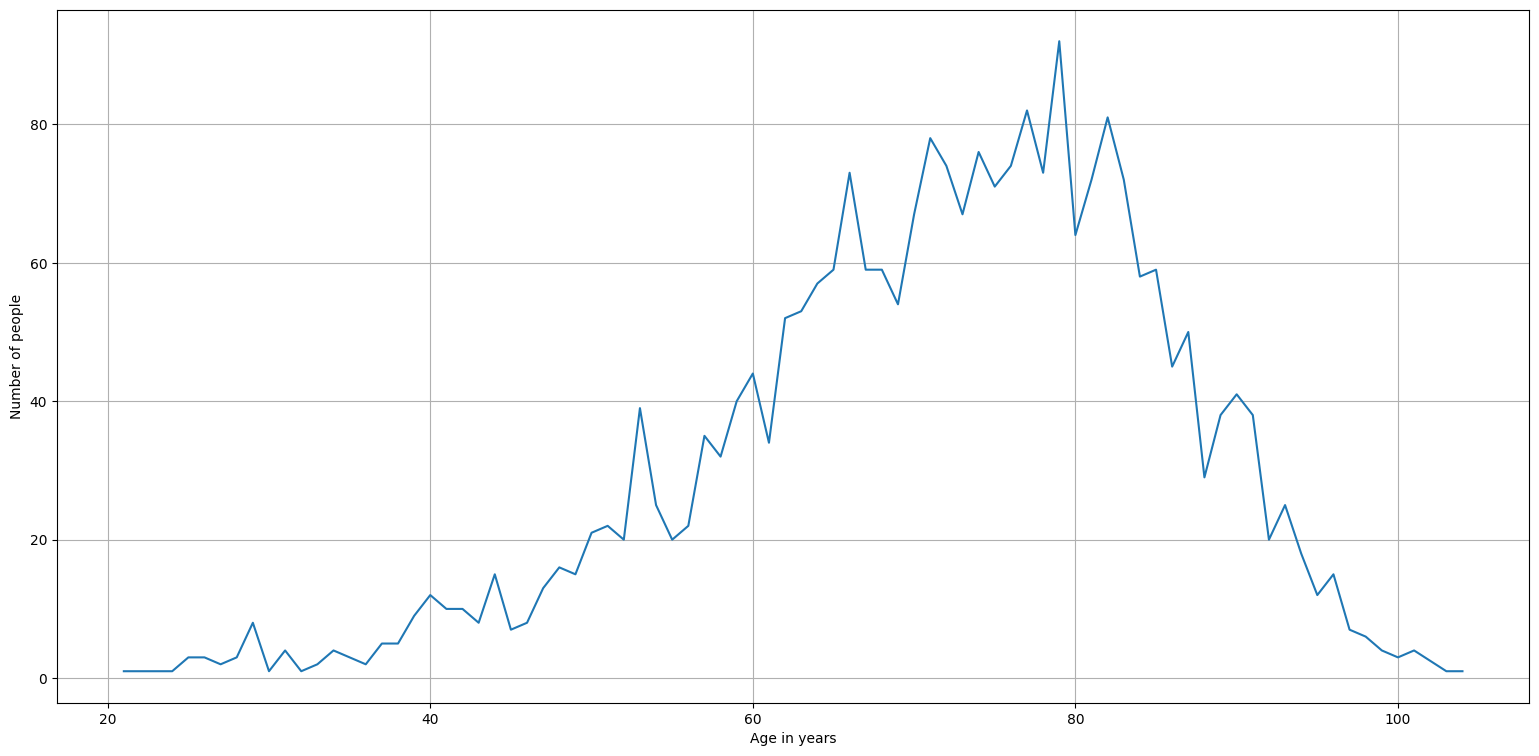

In [ ]:
# Histogram based on ages
cn = Counter(df['age'])

# order by age
XY = OrderedDict(sorted(cn.items(), key=lambda t: t[0]))

# plot the figure
fig = plt.figure(figsize=[19.0, 9.0])
ax = fig.add_subplot(1, 1, 1)

ax.plot(list(XY.keys()), list(XY.values()))

ax.grid()
plt.xlabel('Age in years')
plt.ylabel('Number of people')

plt.show()

## Illustrate the number of people during the history

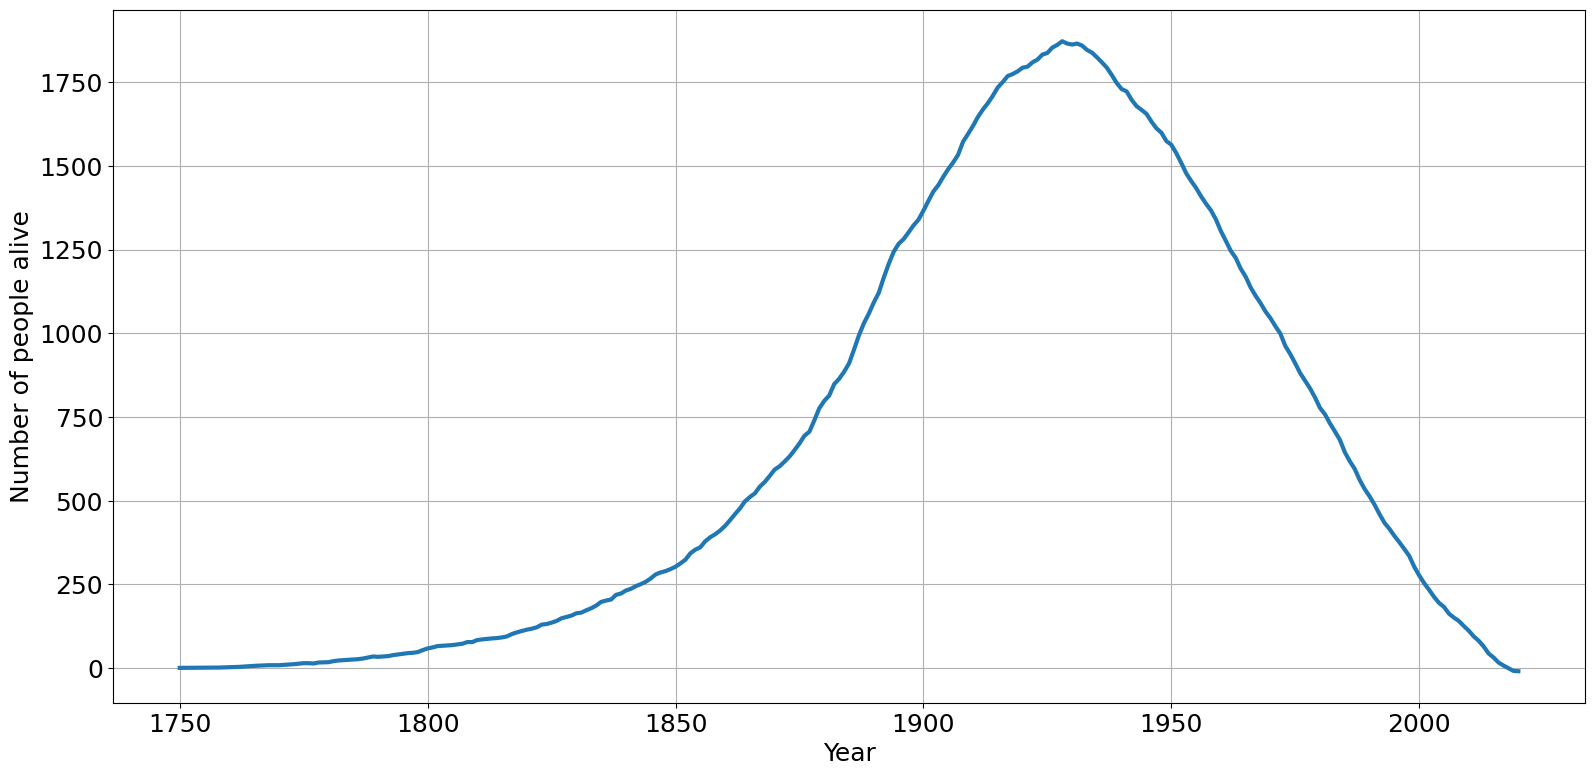

In [ ]:
# Function to convert a date to a year
asYear = lambda d: d.year

# Filter the people who have both the years of birth and death
df2 = df[~(pd.isnull(df.birthtime) | pd.isnull(df.deathtime))]

# convert dates to years
X = df2['birthtime'].apply(asYear)
Y = df2['deathtime'].apply(asYear)

# number of births and deaths for each year
births = Counter(X)
deaths = Counter(Y)

years = sorted(list((births+deaths).keys()))
years = [y for y in years if y>=1750]

# change in the number of people alive for each year:
count = [births[y]-deaths[y] for y in years]

# set up the figure
plt.rcParams.update({'font.size': 18})
fig = plt.figure(figsize=[19.0, 9.0])
ax = fig.add_subplot(1, 1, 1)

# plot the data
plt.plot(years, np.cumsum(count), linewidth=3)

# show the output
plt.xlabel("Year")
plt.ylabel("Number of people alive")
ax.grid()
plt.show()

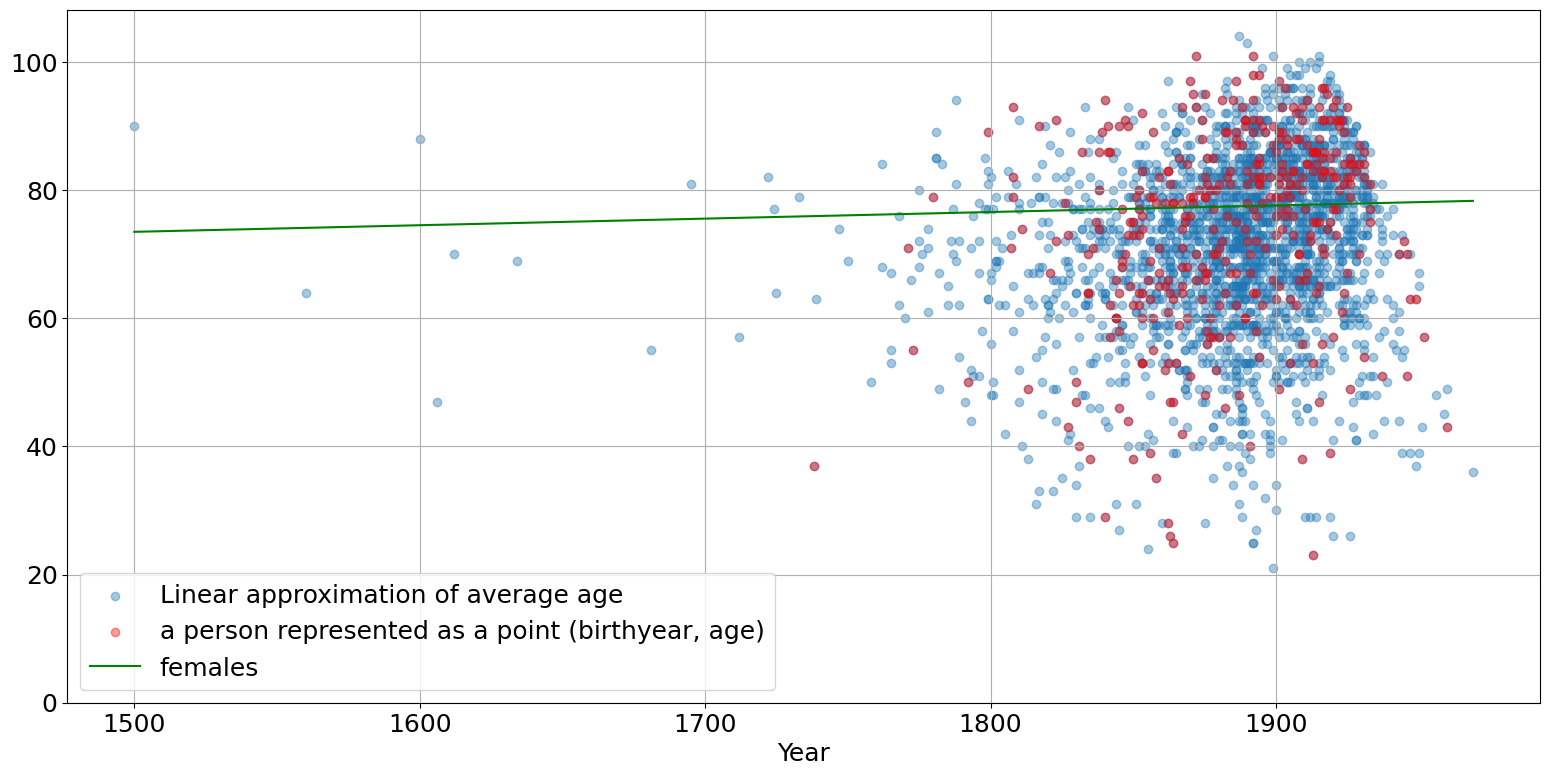

In [ ]:
# years of birth and corresponding ages
X, Y = df['birthtime'].apply(asYear), df['age']
Xrange = [min(X), max(X)]

# average age by linear approximation
ply = np.polyfit(X, Y, 2)

# plot figure
fig = plt.figure(figsize=[19.0, 9.0])
ax = fig.add_subplot(1, 1, 1)

ax.scatter(X,Y, alpha=0.4)

# female biographees
ax.scatter(dff['birthtime'].apply(asYear), dff['age'], c='r', alpha=0.4)

ax.plot(Xrange, np.polyval(ply, Xrange), 'g')

ytick_interval = 20
ax.set_yticks(range(0,max(Y),ytick_interval))

ax.grid()
ax.legend(['Linear approximation of average age', 'a person represented as a point (birthyear, age)', 'females'])
plt.xlabel('Year')
plt.show()


# Query links between people
This linkage is based on how people are mentioned in other people's biographies.

In [ ]:
values = [s.replace('http://ldf.fi/nbf/', 'nbf:') for s in (df.index)[-300:]]

sparql2 = SPARQLWrapper("http://ldf.fi/nbf/sparql")
sparql2.setQuery("""
PREFIX skosxl:  <http://www.w3.org/2008/05/skos-xl#>
PREFIX schema:  <http://schema.org/>
PREFIX foaf:    <http://xmlns.com/foaf/0.1/>
PREFIX rdf:     <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs:    <http://www.w3.org/2000/01/rdf-schema#>
PREFIX nbf:     <http://ldf.fi/nbf/>

SELECT DISTINCT ?source ?target WHERE {
  VALUES ?source { <IDS> }
  VALUES ?target { <IDS> }
  ?source nbf:refers/nbf:target ?target .
} """.replace('<IDS>', ' '.join(values)))

sparql2.setReturnFormat(JSON)
results = sparql2.query().convert()
link_data = JSON2Pandas(results)

init_notebook_mode(all_interactive=False)
display(link_data)

,source,target
0,http://ldf.fi/nbf/p5683,http://ldf.fi/nbf/p2268
1,http://ldf.fi/nbf/p3542,http://ldf.fi/nbf/p4601
2,http://ldf.fi/nbf/p5683,http://ldf.fi/nbf/p4601
3,http://ldf.fi/nbf/p5160,http://ldf.fi/nbf/p5418
4,http://ldf.fi/nbf/p419,http://ldf.fi/nbf/p4690
...,...,...
279,http://ldf.fi/nbf/p5387,http://ldf.fi/nbf/p3867
280,http://ldf.fi/nbf/p5240,http://ldf.fi/nbf/p5062
281,http://ldf.fi/nbf/p2891,http://ldf.fi/nbf/p4567
282,http://ldf.fi/nbf/p4293,http://ldf.fi/nbf/p3935


## Build a [NetworkX](https://networkx.github.io) network from the links.

In [ ]:
G_0=nx.DiGraph()

# feed link results to network
G_0.add_edges_from([e for e in zip(link_data['source'], link_data['target'])])
print(f'Initial network has {G_0.number_of_nodes()} nodes')

# extract the nodes that have at least 2 connections
G = nx.algorithms.core.k_core(G_0, 2)
print(f'Compressed network has {G.number_of_nodes()} nodes')

# pos = nx.drawing.spring_layout(G, pos=None, iterations=500)
pos = nx.drawing.kamada_kawai_layout(G, pos=None)

Initial network has 163 nodes
Compressed network has 103 nodes


Get the most significant, e.g. the most references, people by the centrality measure [pagerank](https://fi.wikipedia.org/wiki/PageRank)

In [ ]:
pagerank = nx.pagerank(G)
ranking = sorted([(k,v) for k,v in pagerank.items()], key=lambda ob: ob[-1], reverse=True)

for k,v in ranking[:12]:
  print("{:.5f}\t{}".format(v,df.loc[k]['fullname']))

0.10412	Mauno Koivisto
0.06081	Kalevi Sorsa
0.03705	Harri Holkeri
0.03064	Olavi Hänninen
0.02787	Markus Kainulainen
0.02753	Paavo Haavikko
0.02586	Ahti Karjalainen
0.02573	Keijo Liinamaa
0.02314	Tuomas Anhava
0.01760	Juha Rihtniemi
0.01658	Brita Koivunen
0.01589	Kaarlo Pitsinki


## Draw the network using [matplotlib](https://matplotlib.org)
There's plenty of commands for [rendering a graph](https://networkx.org/documentation/stable/reference/drawing.html), here we chose to draw the nodes, edges, and labels with separate commands to have a full control of the visual appearance.


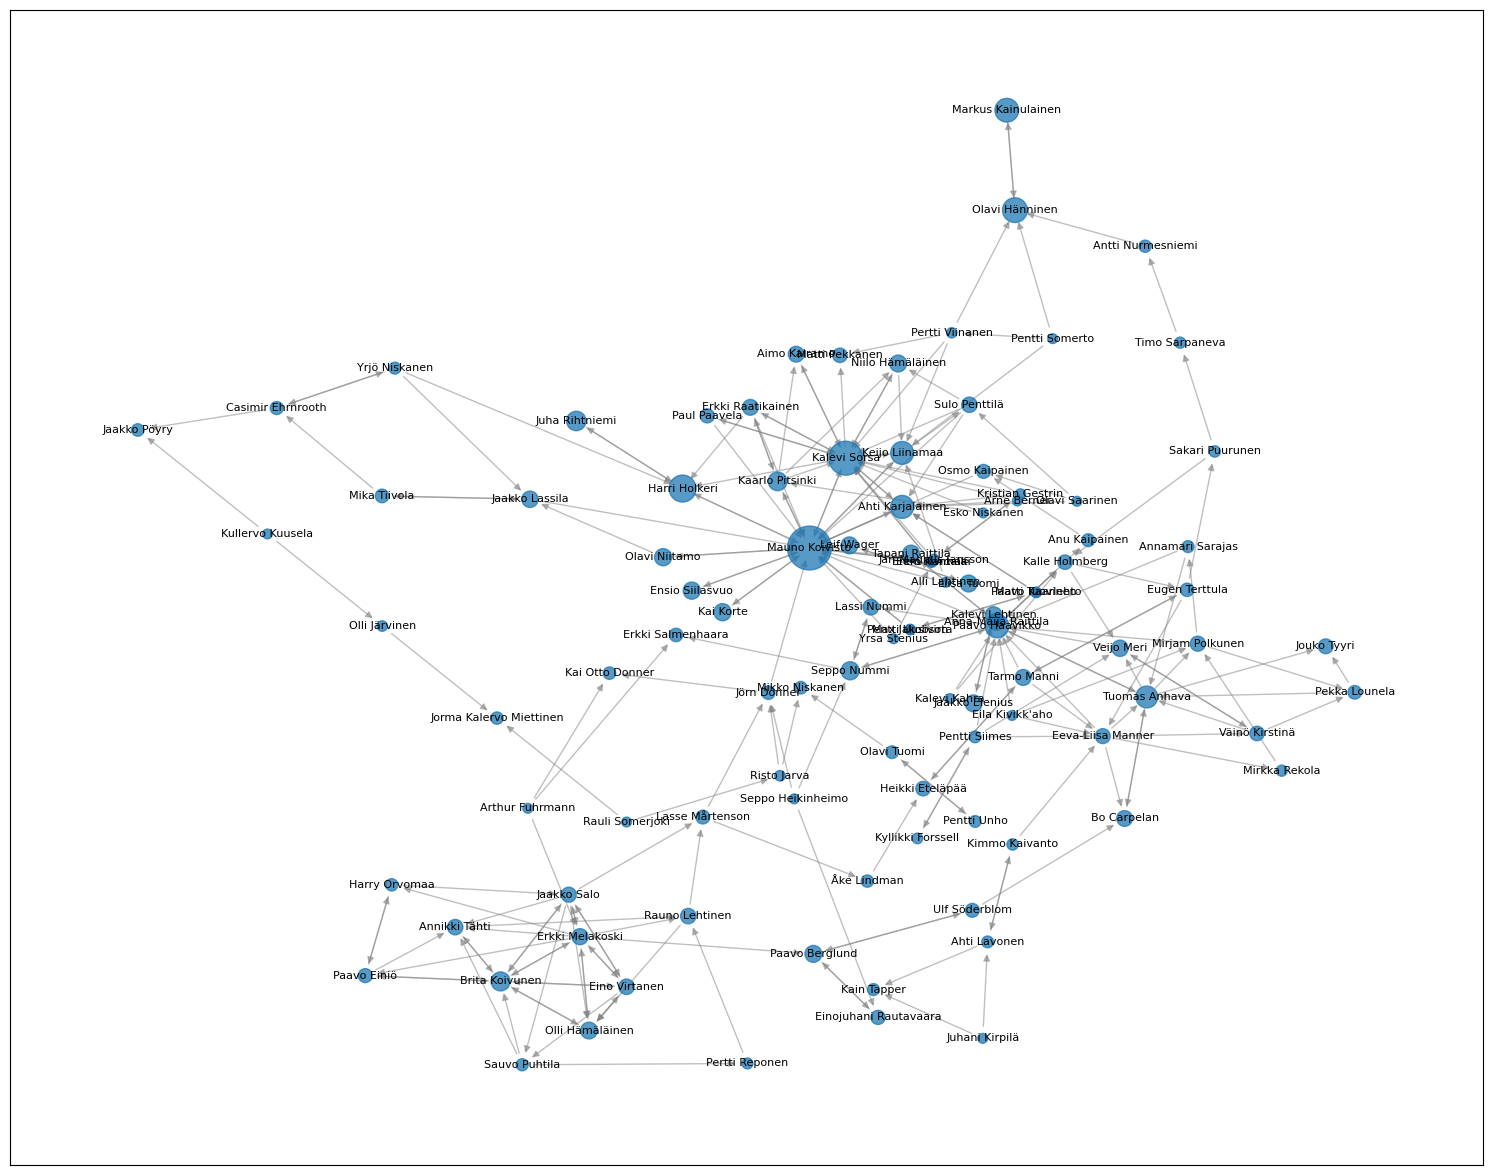

In [ ]:
fig = plt.figure(figsize=[19.0, 15.0])

ax = fig.add_subplot(111)

# Draw network edges first:
nx.drawing.draw_networkx_edges(G,
                              pos=pos,
                              alpha=0.50,
                              edge_color='gray'
                              )

# set node size by the pagerank, and scale it to range [50,1000]:
scale_size = interp1d([min(pagerank.values()),max(pagerank.values())],[50,1000])

nx.drawing.draw_networkx_nodes(G,
                              pos=pos,
                              # Node size proportional to the PageRank value
    												  node_size=scale_size(list(pagerank.values())),
                              alpha=0.75
    												  )

# Show 'fullname' as the node label:
nx.drawing.draw_networkx_labels(G,
                              pos=pos,
                              font_size=8,
                              labels = df.loc[list(G.nodes())]['fullname'])

plt.show()

# People by their categories (Politics, Culture, Economics, ...)

## [Query](https://api.triplydb.com/s/YSxoro7w7) the database
NB: Only people belonging to multiple categories are selected:
```
HAVING (COUNT(DISTINCT ?cat_id)>1)
```



In [ ]:
query="""
PREFIX dct:     <http://purl.org/dc/terms/>
PREFIX foaf:    <http://xmlns.com/foaf/0.1/>
PREFIX skos:    <http://www.w3.org/2004/02/skos/core#>
PREFIX sources: <http://ldf.fi/nbf/sources/>

PREFIX cats: 	<http://ldf.fi/nbf/categories/>
PREFIX nbf:     <http://ldf.fi/nbf/>

SELECT DISTINCT
	?id
	(GROUP_CONCAT(DISTINCT STR(?cat_id);separator=";") AS ?cats)
WHERE {
  ?id a nbf:PersonConcept ;
   dct:source sources:source1 ;
   foaf:focus/nbf:has_category ?cat_id .
}
GROUP BY ?id
HAVING (COUNT(DISTINCT ?cat_id)>1)
"""

sparql = SPARQLWrapper("https://ldf.fi/nbf/sparql")
sparql.setQuery(query)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

res = convertDatatypes(results)

print(f"{len(res)} results")

3655 results


## Map the query results into the 12 main categories

In [ ]:
for ob in res:
  ob['clist'] = list(set([CATEGORY_LOOKUP.get(URIRef(s), 'Other') for s in ob.get('cats', '').split(';')] ))

res = [ob for ob in res if len(ob.get('clist'))>1]

for ob in res[:10]:
  print(ob)

{'id': 'http://ldf.fi/nbf/p579', 'cats': 'http://ldf.fi/nbf/categories/c101;http://ldf.fi/nbf/categories/c133', 'clist': ['Politics', 'Civil Servants']}
{'id': 'http://ldf.fi/nbf/p576', 'cats': 'http://ldf.fi/nbf/categories/c111;http://ldf.fi/nbf/categories/c132', 'clist': ['Politics', 'Judiciary']}
{'id': 'http://ldf.fi/nbf/p575', 'cats': 'http://ldf.fi/nbf/categories/c101;http://ldf.fi/nbf/categories/c111', 'clist': ['Judiciary', 'Civil Servants']}
{'id': 'http://ldf.fi/nbf/p578', 'cats': 'http://ldf.fi/nbf/categories/c101;http://ldf.fi/nbf/categories/c132;http://ldf.fi/nbf/categories/c133', 'clist': ['Politics', 'Civil Servants']}
{'id': 'http://ldf.fi/nbf/p577', 'cats': 'http://ldf.fi/nbf/categories/c101;http://ldf.fi/nbf/categories/c111', 'clist': ['Judiciary', 'Civil Servants']}
{'id': 'http://ldf.fi/nbf/p572', 'cats': 'http://ldf.fi/nbf/categories/c111;http://ldf.fi/nbf/categories/c132', 'clist': ['Politics', 'Judiciary']}
{'id': 'http://ldf.fi/nbf/p571', 'cats': 'http://ldf.fi/

## Number of categories per person

In [ ]:
for k,v in Counter([len(ob.get('clist')) for ob in res]).items():
  print(f'{v} people\twith {k} categories.')

2304 people	with 2 categories.
939 people	with 3 categories.
154 people	with 4 categories.


## List the most common categories

In [ ]:
cn = Counter()
for arr in [ob.get('clist', []) for ob in res]:
  cn.update(arr)

# category 'Other' is used only temporarely
del cn['Other']

cn.most_common()

[('Politics', 1109),
 ('Economics', 982),
 ('Culture', 871),
 ('Science', 730),
 ('Civil Servants', 702),
 ('Charitable and NGO', 575),
 ('Communications', 403),
 ('Military', 394),
 ('Religion', 335),
 ('Education', 293),
 ('Judiciary', 234),
 ('Sports', 139)]

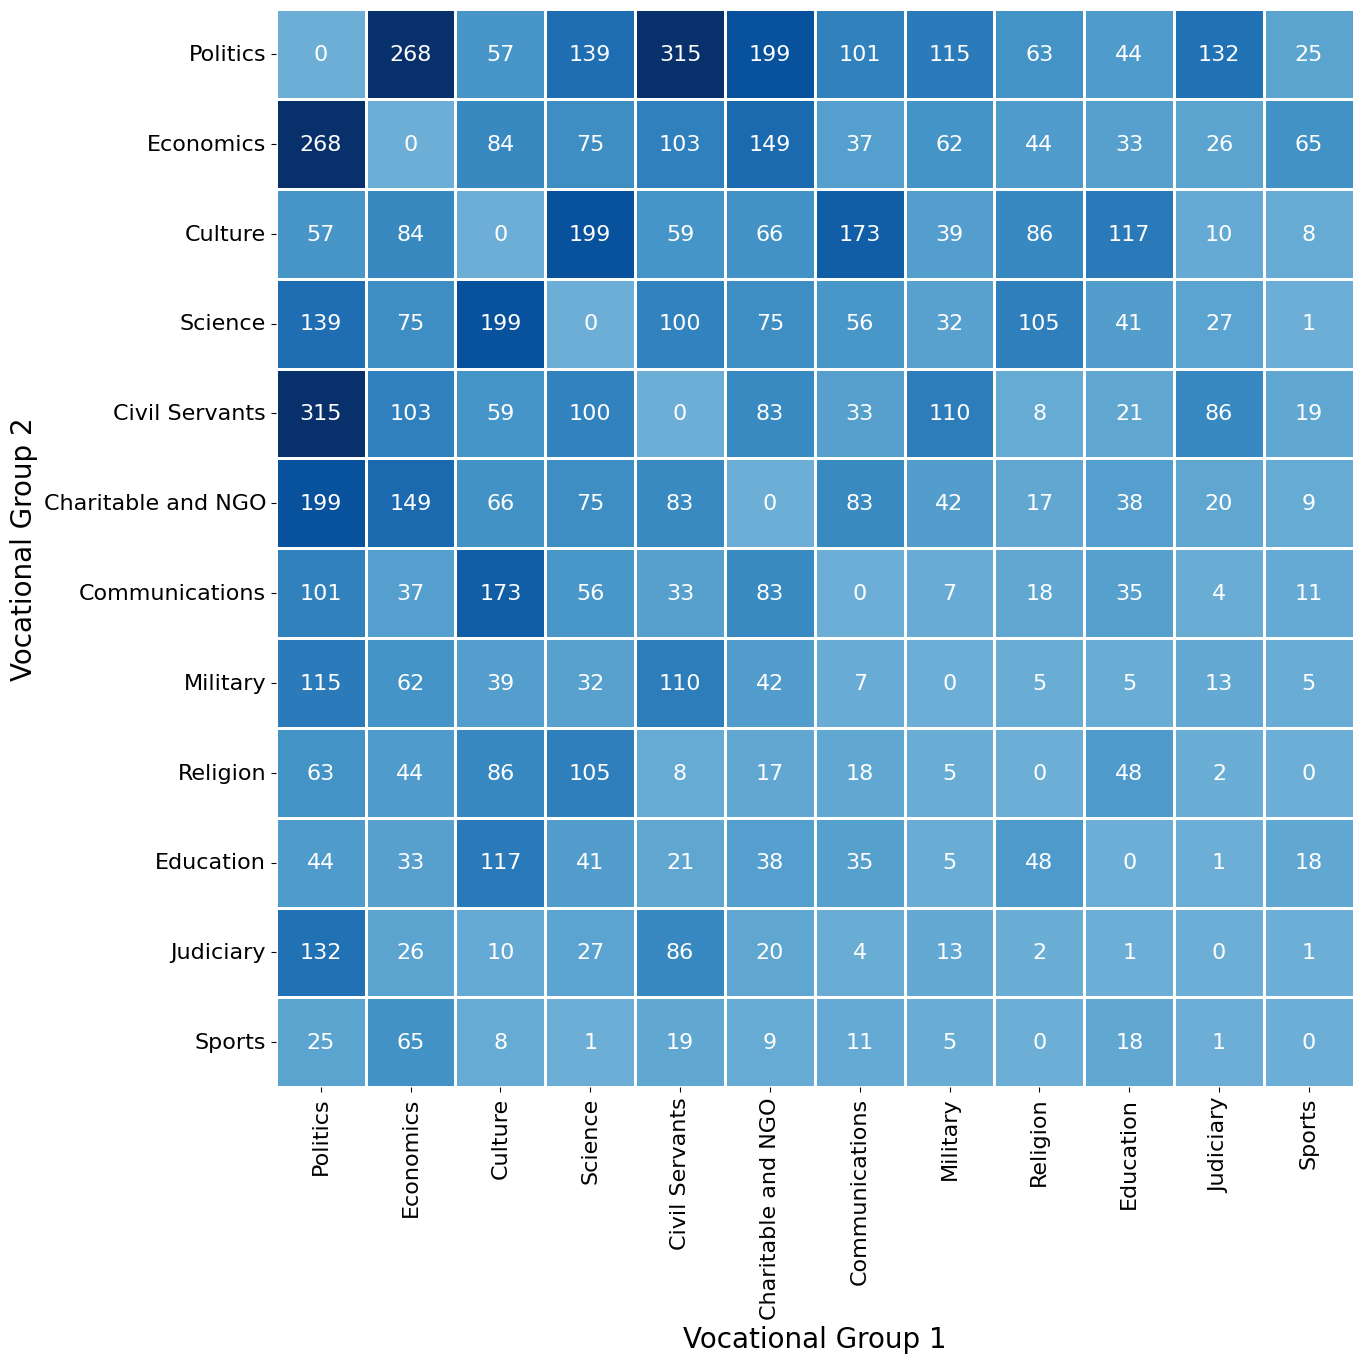

In [ ]:
classes = [k for k,_ in cn.most_common()] # + ['Other']
class_lookup = dict([(k,i) for i,k in enumerate(classes)])

# Initialize a all-zero matrix
C2 = np.zeros((len(classes), len(classes)))

# Loop the list 'A' for each entry
for ob in res:
  arr = ob.get('clist', [])

  ''' Add all pairs from 'clist'
  e.g. [Politics, Economics, Culture]
  =>
  (Politics, Economics), (Politics, Culture), (Economics, Culture)
  '''
  for a,b in combinations(arr,2):
      x = class_lookup.get(a)
      y = class_lookup.get(b)
      if x is not None and y is not None:
        C2[x][y] += 1

# Make the matrix symmetric
C2 += C2.T

# Plot the matrix
plt.rcParams.update({'font.size': 16})
fig, ax = plt.subplots(figsize=(14,14))

sns.heatmap(C2,
            annot = C2,
            center = 0.2,
            fmt = '.0f',
            square = True,
            linewidths = 2,
            robust = True,
            # labels on both x and y axis are the same
            xticklabels = classes,
            yticklabels = classes,
            cbar = False,
            cmap = "Blues",
            cbar_kws = dict(shrink=0.82)
            )

plt.xlabel('Vocational Group 1', fontsize=20)
plt.ylabel('Vocational Group 2', fontsize=20)

# example of exporting a figure from matplotlib:
plt.savefig('Correlation_of_vocations.png', dpi=None, transparent=False, bbox_inches='tight')

plt.show();

# Example of a Map Visualization

## [Query](https://api.triplydb.com/s/xDRVNzPKU) all places within Helsinki area, with events mentioned in Biographysampo

In [ ]:
sparql3 = SPARQLWrapper("http://ldf.fi/nbf/sparql")
sparql3.setQuery("""
PREFIX foaf: <http://xmlns.com/foaf/0.1/>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
PREFIX skosxl: <http://www.w3.org/2008/05/skos-xl#>
PREFIX schema: <http://schema.org/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX wgs84: <http://www.w3.org/2003/01/geo/wgs84_pos#>

PREFIX nbf: <http://ldf.fi/nbf/>

SELECT
	?label ?lat ?long
	(COUNT(DISTINCT ?evt) AS ?count)
WHERE {
  BIND (<http://ldf.fi/nbf/places/Helsinki> AS ?stadi)
  ?id skos:broader+ ?stadi ;
         skos:prefLabel ?label ;
         wgs84:lat ?lat ;
         wgs84:long ?long .
  ?evt nbf:place ?id .
}
GROUP BY ?label ?lat ?long
ORDER BY DESC(?count)
""")

sparql3.setReturnFormat(JSON)

results = sparql3.query().convert()
place_data = JSON2Pandas(results)

display(place_data)

,label,lat,long,count
0,Ateneum,60.170177,24.944092,246
1,Suomen Kansallisteatteri,60.172222,24.943694,107
2,Kallio,60.184169,24.949169,84
3,Sibelius-akatemia,60.174041,24.935198,84
4,Viapori,60.145400,24.988140,82
...,...,...,...,...
165,Viikin Latokartano,60.223634,25.022591,1
166,Villa Ensi,60.155093,24.941368,1
167,Villa Johanna,60.157424,24.941664,1
168,Vuosaari,60.208790,25.143731,1


Install requirements for using Basemap
see [stackoverflow](https://stackoverflow.com/questions/54613992/how-to-install-and-use-basemap-on-google-colab)



```
!apt-get install -q libgeos-3.5.0
!apt-get install libgeos-dev
!pip install https://github.com/matplotlib/basemap/archive/master.zip
!pip install pyproj==1.9.6

%matplotlib inline

from mpl_toolkits.basemap import Basemap
```



In [ ]:
!pip install basemap
!pip install basemap-data-hires

In [ ]:
from mpl_toolkits.basemap import Basemap

Based on this [example](https://colab.research.google.com/github/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/04.13-Geographic-Data-With-Basemap.ipynb#scrollTo=p7Rqt-QNac-5)

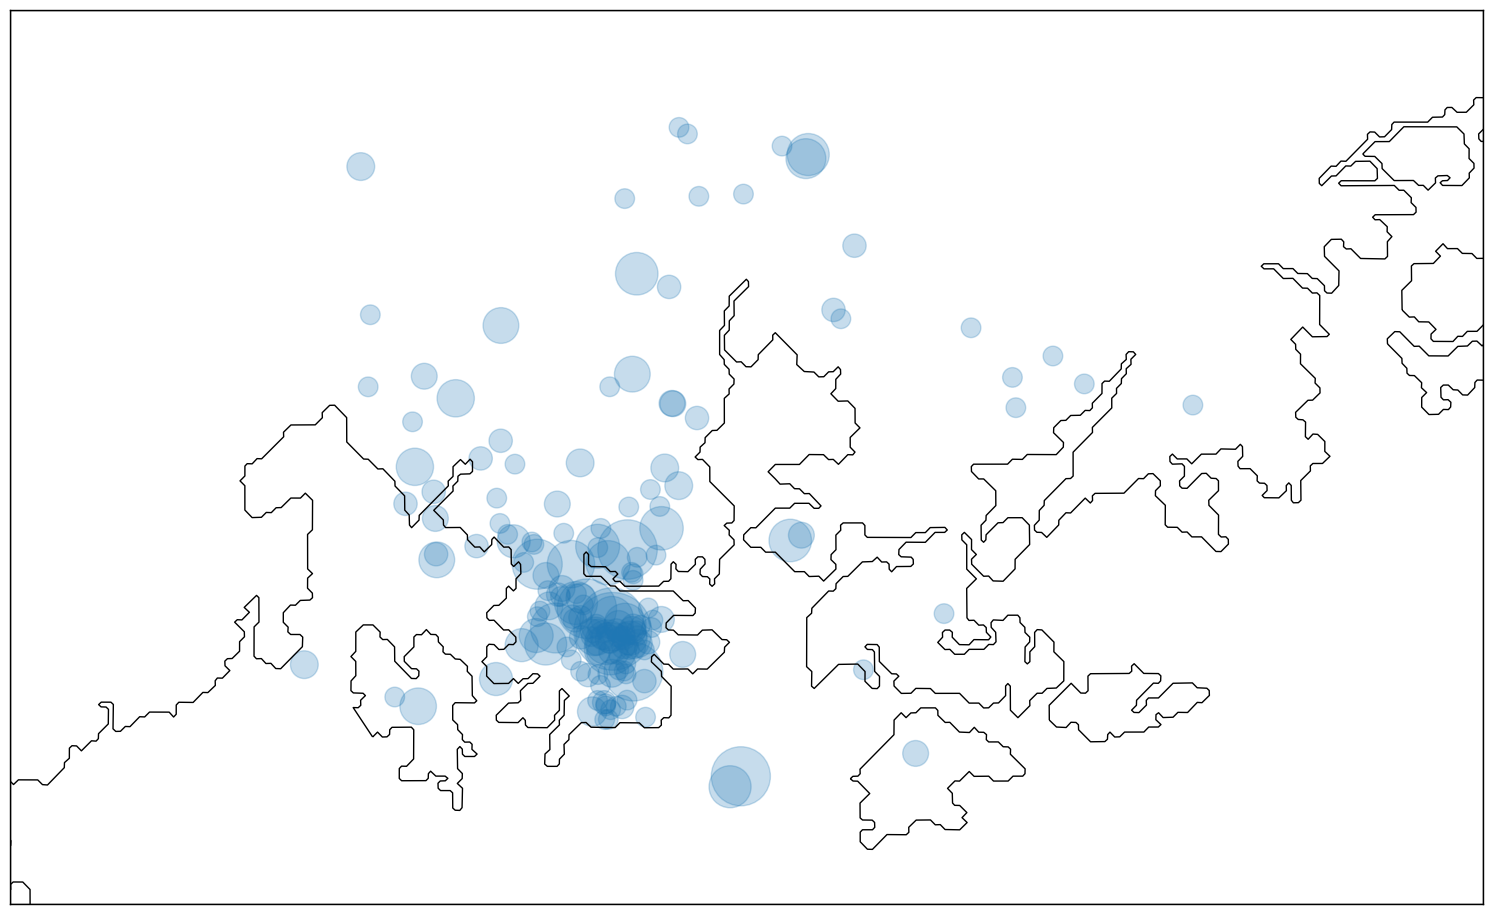

In [ ]:
fig = plt.figure(figsize=(19, 14))
m = Basemap(projection='gnom', resolution='f',
            width=28000, height=17000,
            lat_0=60.2, lon_0=24.99)

m.drawmapboundary(fill_color="#FFFFFF")
m.drawcoastlines()

m.scatter(place_data['long'].values,
          place_data['lat'].values,
          latlon=True,
          # Set marker diameter by the number of events
          s=place_data['count'].apply(lambda x: 200*x**0.5),
          # transparency
          alpha=0.25)

for _,p in place_data.iterrows():
  x, y = m(p['long'], p['lat'])
